--- Dataset Shape ---
Rows: 4324, Columns: 7

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Organisation    4324 non-null   object
 1   Location        4324 non-null   object
 2   Date            4324 non-null   object
 3   Detail          4324 non-null   object
 4   Rocket_Status   4324 non-null   object
 5   Price           964 non-null    object
 6   Mission_Status  4324 non-null   object
dtypes: object(7)
memory usage: 236.6+ KB
None


--- Key Findings Summary ---
Total Recorded Launches: 4,324
Overall Launch Success Rate: 89.71%
Active Rockets Count: 790
Retired Rockets Count: 3,534

--- Cost Statistics ($ Millions) ---
count      964.00
mean       153.79
std        288.45
min          5.30
25%         40.00
50%         62.00
75%        164.00
max      5,000.00
Name: Price_M, dtype: object




C:\Users\kartik\AppData\Local\Temp\ipykernel_16608\2682532468.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\kartik\AppData\Local\Temp\ipykernel_16608\2682532468.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Visualizations successfully generated and saved to 'eda_space_missions_dashboard.png'.


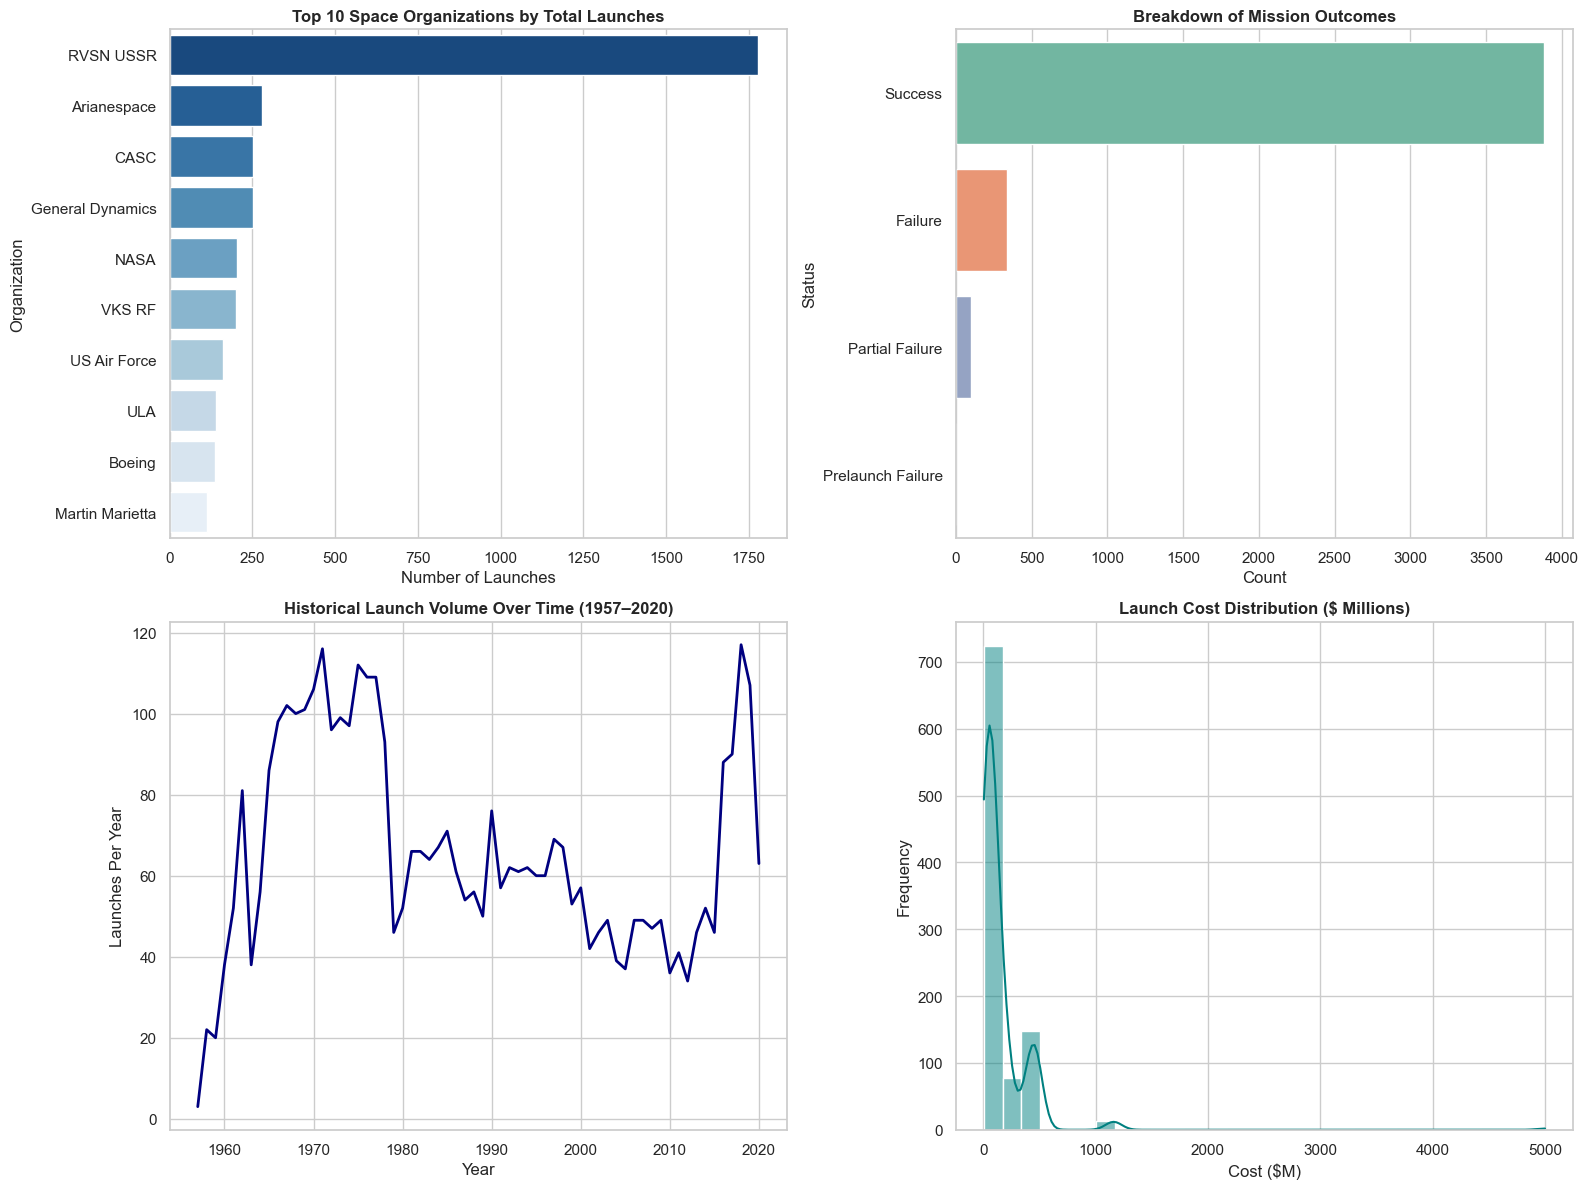

In [1]:
# ==============================================================================
# Exploratory Data Analysis (EDA) on Space Mission Data
# ==============================================================================
# Objective: Clean, transform, analyze, and visualize historical space launch
# data (1957–2020) to uncover trends in launch frequency, costs, success rates,
# and key organizational dynamics.
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure global visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10


# ------------------------------------------------------------------------------
# 1. DATA LOADING & INITIAL INSPECTION
# ------------------------------------------------------------------------------
def load_and_inspect(filepath):
    """Loads the dataset and prints basic structural information."""
    df = pd.read_csv(filepath)

    # Drop redundant index columns if present
    cols_to_drop = [c for c in ["Unnamed: 0.1", "Unnamed: 0"] if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    print("--- Dataset Shape ---")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

    print("--- Data Types & Missing Values ---")
    print(df.info())
    print("\n")

    return df


# ------------------------------------------------------------------------------
# 2. DATA PREPROCESSING & FEATURE ENGINEERING
# ------------------------------------------------------------------------------
def preprocess_data(df):
    """Cleans data types, handles missing values, and derives new features."""

    # Parse 'Date' into standard UTC datetime objects
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)

    # Extract temporal components
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.strftime("%b")

    # Extract Country from Location string (assumed to be the last comma-separated value)
    df["Country"] = df["Location"].apply(
        lambda x: x.split(",")[-1].strip() if pd.notnull(x) else "Unknown"
    )

    # Clean 'Price' column: remove commas and convert to numeric float ($ Millions)
    df["Price_M"] = (
        df["Price"].astype(str).str.replace(",", "", regex=False)
    )
    df["Price_M"] = pd.to_numeric(df["Price_M"], errors="coerce")

    # Clean 'Rocket_Status' string formatting (remove 'Status' prefix if present)
    df["Rocket_Status"] = df["Rocket_Status"].astype(str).str.replace(
        "Status", "", regex=False
    )

    return df


# ------------------------------------------------------------------------------
# 3. STATISTICAL EDA & SUMMARY INSIGHTS
# ------------------------------------------------------------------------------
def generate_summary_statistics(df):
    """Prints key analytical metrics regarding missions, costs, and success rates."""

    total_launches = len(df)
    overall_success_rate = (
        (df["Mission_Status"] == "Success").mean() * 100
    )

    print("--- Key Findings Summary ---")
    print(f"Total Recorded Launches: {total_launches:,}")
    print(f"Overall Launch Success Rate: {overall_success_rate:.2f}%")
    print(
        f"Active Rockets Count: {(df['Rocket_Status'] == 'Active').sum():,}"
    )
    print(
        f"Retired Rockets Count: {(df['Rocket_Status'] == 'Retired').sum():,}"
    )
    print("\n--- Cost Statistics ($ Millions) ---")
    print(df["Price_M"].describe().apply(lambda x: f"{x:,.2f}"))
    print("\n")


# ------------------------------------------------------------------------------
# 4. VISUALIZATION GENERATION
# ------------------------------------------------------------------------------
def generate_visualizations(df):
    """Generates and saves exploratory charts summarizing patterns in the data."""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Visualization 1: Top 10 Launch Organizations
    top_orgs = df["Organisation"].value_counts().head(10)
    sns.barplot(
        x=top_orgs.values,
        y=top_orgs.index,
        ax=axes[0, 0],
        palette="Blues_r",
    )
    axes[0, 0].set_title(
        "Top 10 Space Organizations by Total Launches",
        fontsize=12,
        fontweight="bold",
    )
    axes[0, 0].set_xlabel("Number of Launches")
    axes[0, 0].set_ylabel("Organization")

    # Visualization 2: Distribution of Mission Outcomes
    status_counts = df["Mission_Status"].value_counts()
    sns.barplot(
        x=status_counts.values,
        y=status_counts.index,
        ax=axes[0, 1],
        palette="Set2",
    )
    axes[0, 1].set_title(
        "Breakdown of Mission Outcomes", fontsize=12, fontweight="bold"
    )
    axes[0, 1].set_xlabel("Count")
    axes[0, 1].set_ylabel("Status")

    # Visualization 3: Annual Launch Volume Over Time
    annual_launches = df.groupby("Year").size()
    axes[1, 0].plot(
        annual_launches.index,
        annual_launches.values,
        color="navy",
        linewidth=2,
    )
    axes[1, 0].set_title(
        "Historical Launch Volume Over Time (1957–2020)",
        fontsize=12,
        fontweight="bold",
    )
    axes[1, 0].set_xlabel("Year")
    axes[1, 0].set_ylabel("Launches Per Year")

    # Visualization 4: Distribution of Launch Costs
    sns.histplot(
        df["Price_M"].dropna(),
        kde=True,
        ax=axes[1, 1],
        color="teal",
        bins=30,
    )
    axes[1, 1].set_title(
        "Launch Cost Distribution ($ Millions)", fontsize=12, fontweight="bold"
    )
    axes[1, 1].set_xlabel("Cost ($M)")
    axes[1, 1].set_ylabel("Frequency")

    plt.tight_layout()

    # Save output visualization for presentation/report
    output_filename = "eda_space_missions_dashboard.png"
    plt.savefig(output_filename, dpi=300)
    print(f"Visualizations successfully generated and saved to '{output_filename}'.")
    plt.show()


# ------------------------------------------------------------------------------
# MAIN EXECUTION PIPELINE
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    filepath = "space_mission_data.csv"

    # Step 1: Read & inspect data
    df_raw = load_and_inspect(filepath)

    # Step 2: Clean and transform data
    df_clean = preprocess_data(df_raw)

    # Step 3: Compute summary insights
    generate_summary_statistics(df_clean)

    # Step 4: Render visualization charts
    generate_visualizations(df_clean)